# Práctica 3 - Exploración de un dataset con pandas

## Objetivos

En esta práctica trabajarás con un dataset de clientes utilizando Python.

Al finalizar deberás ser capaz de:

- cargar datos desde un archivo CSV
- trabajar con un `DataFrame` de pandas
- identificar muestras y variables
- consultar la estructura de un dataset
- calcular estadísticas descriptivas
- seleccionar y filtrar datos
- analizar variables categóricas
- crear visualizaciones sencillas
- identificar las características \(X\) y la variable objetivo \(y\)
- determinar qué tipo de problema de Machine Learning podría resolverse

> **Importante:** no debes entrenar ningún modelo de Machine Learning en esta práctica.

## Contexto

Una empresa de telecomunicaciones quiere analizar el comportamiento de sus clientes. Dispone de información histórica y conoce qué clientes terminaron abandonando el servicio.

El objetivo futuro será desarrollar un sistema capaz de predecir:

> **¿Qué clientes tienen riesgo de abandonar la compañía?**

Para realizar la práctica utilizaremos el archivo `clientes.csv`.

| Variable | Descripción |
|---|---|
| `cliente_id` | Identificador del cliente |
| `edad` | Edad del cliente |
| `antiguedad` | Meses como cliente |
| `cuota_mensual` | Cuota mensual en euros |
| `consumo_datos` | Consumo mensual de datos en GB |
| `llamadas_soporte` | Número de llamadas a soporte |
| `incidencias` | Número de incidencias registradas |
| `tipo_contrato` | Mensual, anual o bienal |
| `satisfaccion` | Valoración del servicio de 1 a 5 |
| `abandono` | Indica si el cliente abandonó: Sí/No |

Cada fila corresponde a un cliente.

### Instrucciones

Completa las celdas de código marcadas con `# TODO`.

Cuando se solicite una interpretación, escribe tu respuesta en la celda Markdown correspondiente. No basta con ejecutar código: debes **interpretar los resultados**.

## Parte 1 - Preparación del entorno

### Ejercicio 1 - Importación

Importa NumPy, pandas y Matplotlib utilizando los alias convencionales.

In [46]:
# TODO: importa NumPy, pandas y matplotlib.pyplot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Respuesta

Explica brevemente para qué utilizaremos cada biblioteca:

- **NumPy:** Es la base matematica en la que se basa pandas
- **pandas:** Se usa para trabajar con datos, tablas y series
- **Matplotlib:** se utiliza para crear gráficos y visualizaciones a partir de los datos

## Parte 2 - Carga e inspección inicial

### Ejercicio 2 - Cargar el dataset

Carga `clientes.csv` en un DataFrame denominado `df` y muestra sus primeras filas.

In [47]:
# TODO: carga el archivo clientes.csv en df
df = pd.read_csv('clientes.csv')
# TODO: muestra las primeras filas
df.head()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,tipo_contrato,satisfaccion,abandono
0,10001,23,61.0,32.16,11.9,1,2,Mensual,1,No
1,10002,62,79.0,45.71,17.4,2,0,Anual,2,No
2,10003,55,49.0,60.48,14.6,0,1,Mensual,5,No
3,10004,43,6.0,116.82,21.8,4,0,Anual,3,No
4,10005,43,70.0,36.13,8.8,2,2,Anual,1,Sí


### Respuesta

**¿Qué representa cada fila del DataFrame?**

Cada fila representa a un cliente de la empresa.

**¿Qué representa cada columna?**

Cada columna representa una variable o característica del cliente, como la edad, la antigüedad, la cuota mensual, el tipo de contrato o si abandonó.

### Ejercicio 3 - Dimensiones

Obtén mediante código las dimensiones del dataset.

In [48]:
# TODO: muestra las dimensiones del DaaFrame
df.shape


(180, 10)

### Respuesta

- **Número de muestras:** 180
- **Número de variables:**  10

### Ejercicio 4 - Columnas

Obtén mediante código los nombres de todas las columnas.

In [49]:
# TODO: muestra los nombres de las columnas
df.columns

Index(['cliente_id', 'edad', 'antiguedad', 'cuota_mensual', 'consumo_datos',
       'llamadas_soporte', 'incidencias', 'tipo_contrato', 'satisfaccion',
       'abandono'],
      dtype='str')

### Respuesta

**¿Qué columna parece representar la variable que queremos predecir? ¿Por qué?**

`abandono`, porque indica si el cliente dejó la compañía o no. Esa es la variable que queremos predecir.

### Ejercicio 5 - Tipos de datos

Obtén los tipos de datos de todas las columnas.

In [50]:
# TODO: consulta los tipos de datos
df.dtypes

cliente_id            int64
edad                  int64
antiguedad          float64
cuota_mensual       float64
consumo_datos       float64
llamadas_soporte      int64
incidencias           int64
tipo_contrato           str
satisfaccion          int64
abandono                str
dtype: object

### Respuesta

**Variables numéricas:**
8, aunque `cliente_id` no debería utilizarse como característica predictiva.

**Variables categóricas:**

2: `tipo_contrato` y `abandono`.
**¿`cliente_id` debería considerarse una característica numérica simplemente porque contiene números? Razona la respuesta.**

No. Aunque contiene números, `cliente_id` es un identificador único, no una variable numérica con significado para predecir.

## Parte 3 - Estructura y calidad inicial

### Ejercicio 6 - Información general

Utiliza `info()` para analizar la estructura del dataset.

In [51]:
# TODO: muestra la información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        180 non-null    int64  
 1   edad              180 non-null    int64  
 2   antiguedad        178 non-null    float64
 3   cuota_mensual     180 non-null    float64
 4   consumo_datos     179 non-null    float64
 5   llamadas_soporte  180 non-null    int64  
 6   incidencias       180 non-null    int64  
 7   tipo_contrato     180 non-null    str    
 8   satisfaccion      180 non-null    int64  
 9   abandono          180 non-null    str    
dtypes: float64(3), int64(5), str(2)
memory usage: 14.2 KB


### Respuesta

- ¿Cuántas entradas contiene? 180
- ¿Qué tipos de datos aparecen? Aparecen variables numéricas (`int64` y `float64`) y variables categóricas (`object`).
- ¿Todas las columnas contienen el mismo número de valores no nulos? No.
- ¿Parece existir algún valor ausente? Sí.
- ¿Cómo puedes deducirlo a partir de `info()`? 
Porque algunas columnas tienen menos de 180 valores no nulos: `antiguedad` tiene 178 y `consumo_datos` tiene 179, así que faltan datos.


## Parte 4 - Estadística descriptiva

### Ejercicio 7 - Descripción estadística

Obtén las estadísticas descriptivas de las variables numéricas.

In [52]:
# TODO: genera las estadísticas descriptivas
df.describe()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,satisfaccion
count,180.000000,180.000000,178.000000,180.000000,179.000000,180.000000,180.000000,180.000000
mean,10090.500000,47.283333,62.050562,71.185667,16.408380,1.705556,1.111111,3.016667
std,52.105662,15.929059,33.991071,29.279251,9.813719,1.249345,1.082563,1.423957
min,10001.000000,18.000000,1.000000,20.480000,1.200000,0.000000,0.000000,1.000000
25%,10045.750000,34.000000,34.000000,43.172500,9.800000,1.000000,0.000000,2.000000
50%,10090.500000,47.000000,61.000000,72.690000,14.300000,1.000000,1.000000,3.000000
75%,10135.250000,62.000000,91.750000,97.177500,20.400000,2.250000,2.000000,4.000000
max,10180.000000,75.000000,120.000000,119.440000,54.200000,6.000000,5.000000,5.000000


### Interpretación

A partir del resultado, indica:

- edad media: aproximadamente 47,28 años.
- edad mínima: 18 años.
- edad máxima: 75 años.
- cuota mensual media: aproximadamente 71,19 euros.
- cuota mensual máxima: 119,44 euros.
- media de llamadas a soporte: aproximadamente 1,71 llamadas.
- media de incidencias: aproximadamente 1,11 incidencias.
- satisfacción media: aproximadamente 3,02 sobre 5.



### Ejercicio 8 - Cálculos individuales

Calcula mediante instrucciones independientes los valores solicitados.

In [53]:
# TODO: media de edad
print("Media de edad:", df["edad"].mean())

# TODO: mediana de edad
print("Mediana de edad:", df["edad"].median())

# TODO: cuota mínima
print("Cuota mínima:", df["cuota_mensual"].min())

# TODO: cuota máxima
print("Cuota máxima:", df["cuota_mensual"].max())

# TODO: número total de incidencias
print("Número total de incidencias:", df["incidencias"].sum())

# TODO: satisfacción media
print("Satisfacción media:", df["satisfaccion"].mean())

np.float64(3.0166666666666666)

### Comprobación

¿Coinciden estos resultados con los obtenidos mediante `describe()` cuando corresponde?

Sí, coinciden con `describe()` cuando se trata de estadísticas equivalentes. El total de incidencias no aparece directamente en `describe()`, porque ahí se muestra la media, el mínimo, el máximo y los percentiles.

## Parte 5 - Selección de información

### Ejercicio 9 - Selección de columnas

Crea un DataFrame `df_clientes` que contenga únicamente `edad`, `antiguedad`, `cuota_mensual`, `satisfaccion` y `abandono`. Muestra sus primeras cinco filas.

In [54]:
# TODO: crea df_clientes
df_clientes = df[["edad","antiguedad","cuota_mensual","satisfaccion","abandono"]]
# TODO: muestra las primeras cinco filas
df_clientes.head()

,edad,antiguedad,cuota_mensual,satisfaccion,abandono
0,23,61.0,32.16,1,No
1,62,79.0,45.71,2,No
2,55,49.0,60.48,5,No
3,43,6.0,116.82,3,No
4,43,70.0,36.13,1,Sí


### Respuesta

**¿Sigue representando cada fila al mismo cliente que en el DataFrame original? Explica por qué.**

Sí. Aunque hemos seleccionado menos columnas, no hemos eliminado ni reordenado las filas, así que cada fila sigue correspondiendo al mismo cliente.

## Parte 6 - Filtrado

### Ejercicio 10 - Clientes por edad

Obtén todos los clientes mayores de 50 años y calcula cuántos cumplen la condición.

In [55]:
# TODO: filtra los clientes mayores de 50 años
df_mayores_50 = df.query("edad > 50")

# TODO: calcula cuántos son
num_mayores_50 = df_mayores_50.shape[0]
print(num_mayores_50)
df_mayores_50

77


### Ejercicio 11 - Clientes con incidencias

Selecciona los clientes que tengan `incidencias > 0` y determina cuántos son.

In [56]:
# TODO: filtra los clientes con incidencias
df_incidencias = df.query("incidencias > 0")

# TODO: calcula cuántos son
total_incidencias = df_incidencias.shape[0]
print(total_incidencias)


120


### Ejercicio 12 - Condiciones combinadas

Obtén los clientes que cumplan simultáneamente:

\[
edad < 30
\]

y

\[
llamadas\_soporte \geq 3
\]

Muestra únicamente `cliente_id`, `edad`, `llamadas_soporte` y `abandono`.

In [57]:
# TODO: realiza el filtro y muestra únicamente las columnas solicitadas
df_12 = df.query("edad < 30 and llamadas_soporte >= 3")
df_12 = df_12[["cliente_id", "edad", "llamadas_soporte", "abandono"]]
df_12

,cliente_id,edad,llamadas_soporte,abandono
17,10018,25,3,No
22,10023,28,3,No
35,10036,21,3,Sí
55,10056,20,3,No
101,10102,29,3,No
117,10118,26,3,Sí
119,10120,24,3,No
132,10133,23,4,No
146,10147,20,3,No
167,10168,27,6,Sí


### Respuesta

**¿Qué operador has utilizado para combinar ambas condiciones?**

He utilizado el operador `and` dentro de `query()` para exigir que se cumplan las dos condiciones a la vez. Después he seleccionado las columnas pedidas con dobles corchetes.

### Ejercicio 13 - Segundo filtro combinado

Localiza clientes que cumplan:

\[
satisfaccion \leq 2
\]

y

\[
incidencias \geq 2
\]

Muestra las filas encontradas.

In [67]:
# TODO: realiza el filtro
df_13 = df.query("satisfaccion <= 2  and incidencias >= 2")
df_13 = df_13[["satisfaccion","incidencias", "cliente_id"]]
print(df_13)


     satisfaccion  incidencias  cliente_id
0               1            2       10001
4               1            2       10005
5               2            2       10006
11              1            5       10012
19              1            2       10020
20              2            2       10021
24              1            2       10025
25              2            2       10026
35              1            2       10036
44              1            2       10045
46              2            4       10047
50              2            2       10051
59              2            3       10060
61              1            2       10062
62              2            4       10063
65              1            2       10066
67              1            3       10068
89              2            2       10090
104             1            2       10105
113             1            2       10114
129             1            2       10130
140             1            2       10141
141        

### Reflexión

**Observando únicamente estos resultados, ¿podemos afirmar que una satisfacción baja provoca el abandono?**

Justifica tu respuesta.

No. Con ese filtro solo vemos clientes que tienen baja satisfacción y varias incidencias, pero eso no demuestra causalidad. Para afirmar que la baja satisfacción provoca el abandono habría que hacer un análisis más completo y comparar con otros clientes y variables.

## Parte 7 - Variables categóricas

### Ejercicio 14 - Tipo de contrato

Obtén los diferentes valores de `tipo_contrato` y calcula cuántos clientes pertenecen a cada categoría.

In [66]:
# TODO: muestra las categorías existentes
print(df["tipo_contrato"].unique())

# TODO: calcula la frecuencia de cada categoría
print("Frecuencia" , df["tipo_contrato"].value_counts())

<StringArray>
['Mensual', 'Anual', 'Bienal']
Length: 3, dtype: str
Frecuencia tipo_contrato
Mensual    94
Anual      56
Bienal     30
Name: count, dtype: int64


### Respuesta

**¿Cuál es el tipo de contrato más frecuente?**

Mensual

### Ejercicio 15 - Variable `abandono`

Obtén las categorías existentes, el número de clientes de cada categoría y sus frecuencias relativas.

In [72]:
# TODO: categorías existentes
print("Categorias: ",df["abandono"].unique())


# TODO: frecuencias absolutas
print("Frecuencia: ", df["abandono"].value_counts())

# TODO: frecuencias relativas
print("Frecuencia: ", df["abandono"].value_counts(normalize=True))


Categorias:  <StringArray>
['No', 'Sí']
Length: 2, dtype: str
Frecuencia:  abandono
No    110
Sí     70
Name: count, dtype: int64
Frecuencia:  abandono
No    0.611111
Sí    0.388889
Name: proportion, dtype: float64


### Interpretación

Expresa las frecuencias relativas mediante porcentajes y redacta una breve conclusión sobre la distribución de `abandono`.

Sí. La mayoría se queda, pero casi 4 de cada 10 abandonan

## Parte 8 - Visualización

Todos los gráficos deben contener como mínimo:

- título;
- etiquetas de los ejes cuando correspondan;
- una representación clara.

### Ejercicio 16 - Distribución de edad

Construye un histograma de `edad`.

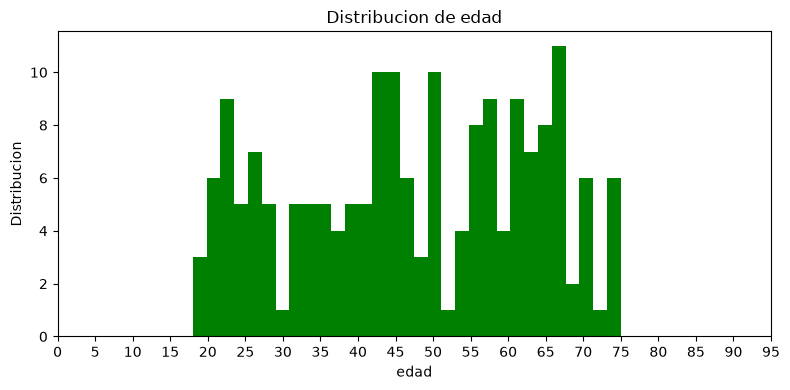

In [94]:
# TODO: crea el histograma de edad
plt.figure(figsize=(8,4)) #8x4 de pulgadas
plt.hist(df["edad"], bins=31 , color="green")#bins ancho de los datos
plt.xticks(range(0,100,5))
plt.xlabel("edad")
plt.ylabel("Distribucion")
plt.title("Distribucion de edad")
plt.tight_layout()

### Interpretación

**¿Qué información proporciona un histograma que no resulta tan fácil obtener observando directamente las filas del DataFrame?**

Muestra la forma de la distribución (rango, concentraciones, huecos) de un vistazo.

### Ejercicio 17 - Abandono

Representa mediante un gráfico de barras el número de clientes que abandonaron y que no abandonaron.

Index(['No', 'Sí'], dtype='str', name='abandono')
[110  70]


Text(0.5, 1.0, 'Abdandono de clientes')

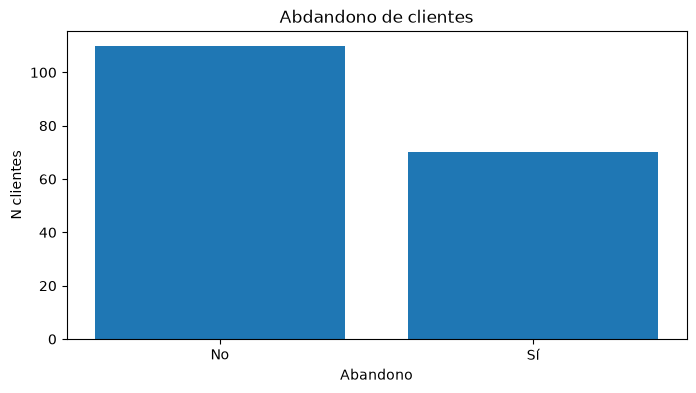

In [ ]:
# TODO: crea el gráfico de barras
n_abandonos = df["abandono"].value_counts()
print(n_abandonos.index)
print(n_abandonos.values)

plt.figure(figsize=(8,4))
plt.bar(n_abandonos.index, n_abandonos.values)
plt.xlabel("Abandono")
plt.ylabel("N clientes")
plt.title("Abdandono de clientes")



### Interpretación

Describe brevemente qué muestra el gráfico.

Hay más clientes que no abandonan (110) que los que sí (70)

### Ejercicio 18 - Cuota mensual

Crea un histograma para `cuota_mensual`.

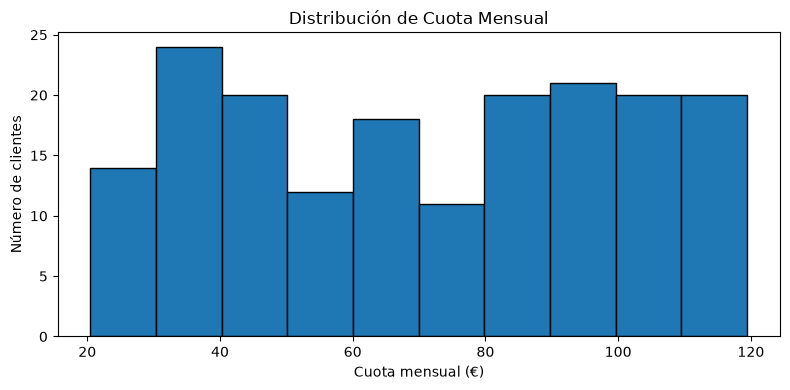

In [103]:
plt.figure(figsize=(8, 4))

# 1. Usar plt.hist con la columna directa
plt.hist(df["cuota_mensual"], bins=10, edgecolor="black")

plt.xlabel("Cuota mensual (€)")
plt.ylabel("Número de clientes")
plt.title("Distribución de Cuota Mensual")

plt.tight_layout()
plt.show()

### Interpretación

Analiza visualmente la distribución.

Las cuotas van de ~20 a ~120 €. Hay un grupo con cuotas bajas (30-40 €) y otro con cuotas altas (80-120 €), sin forma de campana ni valores extremos.

### Ejercicio 19 - Edad y cuota

Crea un diagrama de dispersión utilizando:

\[
x = edad
\]

\[
y = cuota\_mensual
\]

Text(0.5, 1.0, 'Dispersion edad cuota')

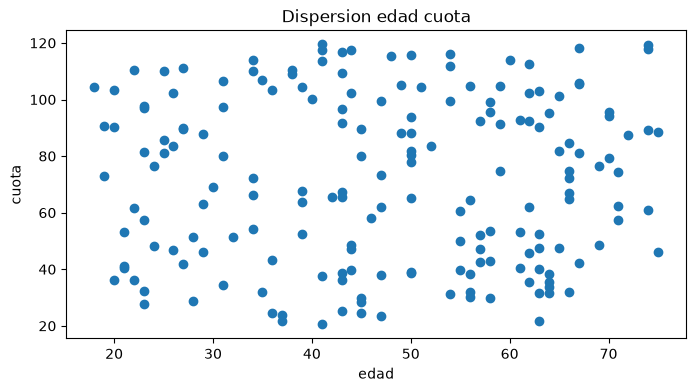

In [105]:
# TODO: crea el diagrama de dispersión

plt.figure(figsize=(8,4))
plt.scatter(df["edad"], df["cuota_mensual"])

plt.xlabel("edad")
plt.ylabel("cuota")
plt.title("Dispersion edad cuota")


### Interpretación

- ¿Qué representa cada punto?
Cada punto es un cliente (edad, cuota).
- ¿Observas a simple vista alguna relación clara entre ambas variables?
No se ve una relación clara: hay cuotas bajas y altas en todas las edades.

No es necesario realizar un análisis estadístico.



## Parte 9 - Identificación de $X$ e $y$

La empresa quiere construir en el futuro un modelo que determine si un cliente abandonará.

### Ejercicio 20 - Variable objetivo

Identifica y crea `y`. Después muestra sus cinco primeros valores.

In [106]:
# TODO: crea y
y = df["abandono"]

# TODO: muestra sus cinco primeros valores
y.head()

0    No
1    No
2    No
3    No
4    Sí
Name: abandono, dtype: str

### Respuesta

**¿Por qué esta variable corresponde a \(y\)?**

Porque abandono es lo que queremos predecir

### Ejercicio 21 - Características

Crea `X` utilizando inicialmente estas características:

- `edad`
- `antiguedad`
- `cuota_mensual`
- `consumo_datos`
- `llamadas_soporte`
- `incidencias`
- `tipo_contrato`
- `satisfaccion`

Después comprueba sus dimensiones.

In [109]:
# TODO: crea X
X = df[["edad", "antiguedad", "cuota_mensual", "consumo_datos", "llamadas_soporte", "incidencias", "tipo_contrato", "satisfaccion"]]

# TODO: muestra las dimensiones de X
print(X.shape)

(180, 8)


### Respuesta

Si el dataset contiene \(n\) clientes, esperamos:

\[
X.shape = (n,\ ?)
\]

**¿Qué número debe aparecer en `?`? ¿Por qué?**

8 por las columnas y 180 por las filas

## Parte 10 - Razonamiento de Machine Learning

### Ejercicio 22 - Identificación del problema

Queremos predecir:

`abandono → Sí / No`

Responde razonadamente:

1. ¿Estamos ante aprendizaje supervisado o no supervisado?
Supervisado
2. ¿Por qué?
Porque tenemos la etiqueta abandono conocida en los datos históricos.
3. ¿Es clasificación o regresión?
Clasificación
4. ¿Por qué?
Porque se predice una categoría, no un número.
5. ¿Es clasificación binaria o multiclase?
Binaria
6. ¿Cuáles son las clases?
Si y no

### Respuesta

Aprendizaje supervisado de clasificación binaria: hay etiqueta conocida (`abandono`) y solo dos clases posibles, Sí y No.

## Parte 11 - Un cambio en el problema

Supongamos ahora que la empresa plantea:

> Queremos predecir cuál será el **consumo de datos del próximo mes** de cada cliente.

### Ejercicio 23

Responde:

1. ¿Cuál sería ahora la variable objetivo?
El consumo de datos del próximo mes.
2. ¿Seguiríamos teniendo exactamente el mismo \(X\)?
No exactamente: consumo_datos ya no sería característica, y abandono podría pasar a serlo.
3. ¿Sería clasificación o regresión?
Regresión
4. ¿Seguiría siendo aprendizaje supervisado?
Si
5. Justifica cada respuesta.
La variable objetivo ahora es numérica y continua, y seguimos teniendo valores reales con los que aprender.


## Parte 12 - Análisis crítico

### Ejercicio 24 - ¿Utilizarías `cliente_id`?

Los identificadores tienen valores como:

`10001, 10002, 10003, 10004, ...`

¿Utilizarías esta columna como característica para predecir el abandono?

No respondas únicamente «sí» o «no». Razona tu decisión.

### Respuesta

No. Es solo un identificador arbitrario, sin relación con el comportamiento del cliente. Podría generar patrones casuales y no sirve para clientes nuevos.

### Ejercicio 25 - ¿Estamos preparados para entrenar?

Después del análisis anterior, alguien propone ejecutar directamente:

```python
modelo.fit(X, y)
```

¿Estamos preparados?

Identifica **al menos cuatro cuestiones** que deberíamos estudiar o resolver antes de entrenar el modelo.

No necesitas explicar todavía cómo resolverlas.

### Respuesta

No, todavía no estamos preparados para entrenar directamente el modelo. Antes habría que revisar o resolver, como mínimo, estas cuestiones:

1. Tratar los valores ausentes detectados en `antiguedad` y `consumo_datos`.
2. Codificar las variables categóricas, especialmente `tipo_contrato`, para que el modelo pueda trabajar con ellas.
3. Decidir si hay que transformar la variable objetivo `abandono` de `Sí`/`No` a un formato numérico o categórico adecuado.
4. Separar los datos en entrenamiento y prueba para poder evaluar el modelo con datos no vistos.
5. Comprobar si las clases de `abandono` están equilibradas o si existe desbalance.
6. Revisar si conviene escalar o normalizar variables numéricas como `cuota_mensual`, `consumo_datos` o `antiguedad`.
7. Confirmar que no se incluyen variables poco útiles o problemáticas, como `cliente_id`, dentro de las características.

## Parte 13 - Conclusiones

### Ejercicio 26 - Informe final

Escribe entre **8 y 12 líneas** resumiendo lo que has descubierto.

Debes incluir como mínimo:

- tamaño del dataset
- principales tipos de variables
- comportamiento de `abandono`
- alguna observación de las estadísticas
- alguna observación de las visualizaciones
- cuáles son \(X\) e \(y\)
- tipo de problema de Machine Learning
- qué pasos deberían realizarse antes de entrenar

### Conclusiones

### Conclusiones

El dataset tiene 180 clientes y 10 variables, con algunos valores ausentes en antiguedad y consumo_datos. El 61,1 % no abandona y el 38,9 % sí. La edad media es de 47 años, la cuota media de 71 € y la satisfacción media de 3,02. Los gráficos muestran edades repartidas y cuotas en dos bloques, sin relación clara entre edad y cuota. y es abandono y X tiene 8 características: es un problema de clasificación binaria supervisada. Antes de entrenar hay que tratar los ausentes, codificar las categóricas y dividir en entrenamiento y prueba.

---

# Ampliación opcional

Si terminas antes, investiga cómo obtener con pandas:

1. El número exacto de valores ausentes de cada columna.
2. El número de clientes agrupados por `tipo_contrato` y `abandono`.
3. La cuota mensual media de quienes abandonaron y de quienes no.
4. La satisfacción media de ambos grupos.

No utilices algoritmos de Machine Learning.

In [36]:
# AMPLIACIÓN OPCIONAL

# 1. Valores ausentes por columna
df.isna().sum()

# 2. Clientes agrupados por tipo_contrato y abandono
df.groupby(["tipo_contrato","abandono"]).size()

# 3. Cuota mensual media según abandono
df.groupby("abandono")["cuota_mensual"].mean().round(2)

# 4. Satisfacción media según abandono
df.groupby("abandono")["satisfaccion"].mean().round(2)

abandono
No    3.35
Sí    2.50
Name: satisfaccion, dtype: float64

# Antes de entregar

Comprueba que:

- has completado todas las celdas `TODO`
- has respondido las preguntas en Markdown
- todos los gráficos tienen título y etiquetas
- has reiniciado el entorno y ejecutado el notebook completo desde el principio
- no se producen errores
- no has entrenado ningún modelo

**Nombre recomendado del archivo de entrega:**

`Practica_03_Apellido_Nombre.ipynb`